In [2]:
from PIL import Image, ImageOps
import numpy as np, os

src = ""
if os.path.exists(src):
    img = ImageOps.exif_transpose(Image.open(src)).convert("RGB")
    ImageOps.fit(img, (320, 240)).save("sample.jpg")
else:
    yy, xx = np.mgrid[0:240, 0:320]
    img = np.stack([(xx / 320 * 255).astype(np.uint8),
                    (yy / 240 * 255).astype(np.uint8),
                    np.full((240, 320), 120, np.uint8)], axis = -1)
    img[(xx - 160) ** 2 + (yy - 120) ** 2 < 60 ** 2] = 255
    Image.fromarray(img).save("sample.jpg")
    
print(np.array(Image.open("sample.jpg")).shape)

(240, 320, 3)


In [3]:
from PIL import Image
import numpy as np

img = Image.open("sample.jpg")
a = np.array(img)

print(a.shape, a.dtype)
print(a[0, 0])
print(a[120, 160])
print(a.min(), a.max())
print(a[:, :, 0].mean().round(1))

(240, 320, 3) uint8
[  0   0 118]
[255 255 255]
0 255
145.3


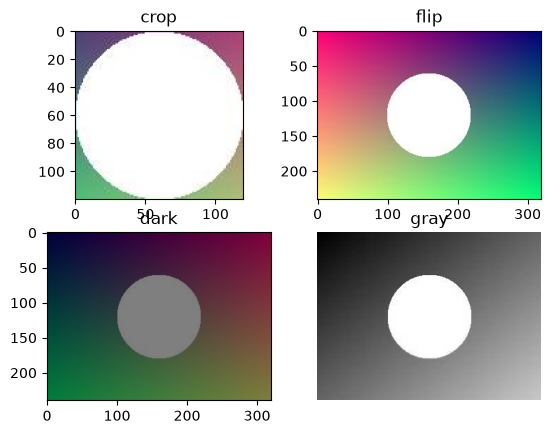

(120, 120, 3) (240, 320, 3) (240, 320)


In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

a = np.array(Image.open("sample.jpg"))
crop = a[60:180, 100:220]
flip = a[:, ::-1]
dark = (a * 0.5).astype(np.uint8)
gray = a.mean(axis = 2).astype(np.uint8)
pairs = [("crop", crop), ("flip", flip), ("dark", dark), ("gray", gray)]
for i, (name, im) in enumerate(pairs):
    plt.subplot(2, 2, i + 1); plt.imshow(im, cmap = 'gray'); plt.title(name)
plt.axis("off")
plt.show()
print(crop.shape, flip.shape, gray.shape)

torch.Size([28, 28]) 255 0
..............######........
...........####.##..##......
........###.........###.....
.......##...........###.....
.......##........###........
.......##########...........


C:\Users\user\AppData\Local\Temp\ipykernel_16548\4212952356.py:7: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  t = torch.tensor(list(img.getdata())).view(28, 28)


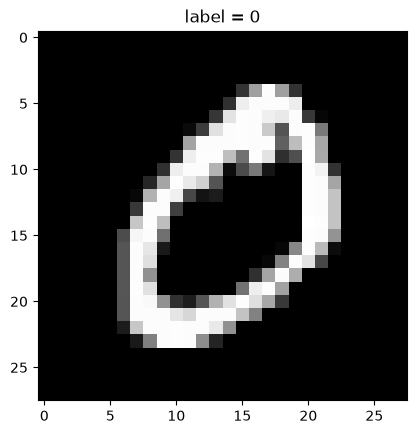

In [11]:
import matplotlib.pyplot as plt
import torch
from torchvision import datasets

mnist = datasets.MNIST(root = 'data', train = True, download = True)
img, label = mnist[1]
t = torch.tensor(list(img.getdata())).view(28, 28)
print(t.shape, t.max().item(), label)
for row in t[6:22:3]:
    print("".join("#" if v > 128 else "." for v in row))
plt.imshow(t.numpy(), cmap = "gray"); plt. title(f"label = {label}"); plt.show()

(240, 320, 3)


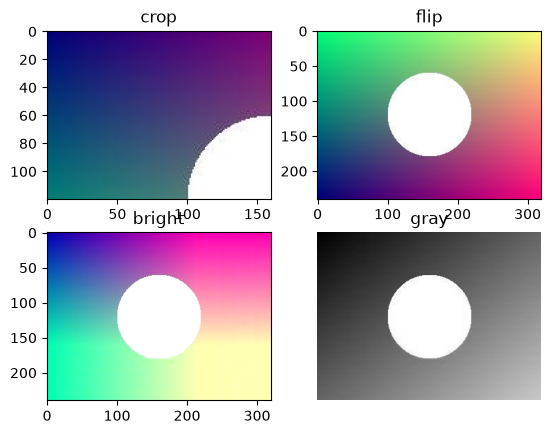

(120, 160, 3) (240, 320, 3) (240, 320)


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

a = np.array(Image.open("sample.jpg"))
print(a.shape)

crop = a[0:120, 0:160]
flip = a[::-1]
bright = np.clip(a * 1.5, 0, 255).astype(np.uint8) 
gray = a.mean(axis = 2).astype(np.uint8)

pairs = [("crop", crop), ("flip", flip), ("bright", bright), ("gray", gray)]
for i, (name, im) in enumerate(pairs):
    plt.subplot(2, 2, i + 1); plt.imshow(im, cmap = 'gray'); plt.title(name)
plt.axis("off")
plt.show()
print(crop.shape, flip.shape, gray.shape)